<a href="https://colab.research.google.com/github/slave8/aistudy/blob/main/%ED%8C%8C%EC%9D%B4%EC%8D%AC%EA%B8%B0%EB%B3%B8%EB%AC%B8%EB%B2%953_%EA%B0%95%EB%AF%BC%EA%B5%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##구글 드라이브 마운트
로컬에 있는 파일을 구글 드라이브에 업로드한 후 사용하기 위함

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Pandas 기초

### pandas 모듈 포함하기

In [ ]:
import pandas as pd

### 시리즈(Series)와 데이터프레임(DataFrame)
* 시리즈(Series)
  * 1차원 배열로서 단일 변수 데이터를 저장하는 데 사용된다.
* 데이터프레임(DataFrame)
  * 2차원 배열로서 다중 변수 데이터를 저장하는 데 사용된다.
  * 데이터프레임은 여러 개의 1차원 배열(시리즈)을 세로 방향으로 묶어 놓은 형태를 가진다.


### 시리즈 객체 생성


In [ ]:
# Series 생성 (1차원 데이터)
temperatures = pd.Series([23.5, 25.1, 19.8, 30.2])
print(temperatures)
print(temperatures.iloc[2]) # 인덱스로 원소에 접근

0    23.5
1    25.1
2    19.8
3    30.2
dtype: float64
19.8


In [ ]:
temperatures.index = ['월', '화', '수', '목'] # 의미있는 인덱스레이블 부여하기
temperatures.index.name = '요일'
temperatures.name = '온도' # 컬럼 이름
display(temperatures)
print(temperatures.loc['수']) #레이블로 원소에 접근

,온도
요일,
월,23.5
화,25.1
수,19.8
목,30.2


19.8


In [ ]:
# Series 생성 (레이블 및 이름 포함)
temperatures = pd.Series([23.5, 25.1, 19.8, 30.2],
                       index=['월', '화', '수', '목'],
                        name='온도')
print(temperatures)

월    23.5
화    25.1
수    19.8
목    30.2
Name: 온도, dtype: float64


In [ ]:
score = pd.Series([100,98,99])
score.index = ['박재휘','이규성','이재희']
score.index.name = '이름'
score.name = '시험성적'
display(score)
print(score.loc['이규성'])

,시험성적
이름,
박재휘,100
이규성,98
이재희,99


98


In [ ]:
score = pd.Series([100,98,99],
                  index=['박재휘','이규성','이재희'],
                  name='시험성적')
display(score)
print(score.loc['이규성'])

,시험성적
박재휘,100
이규성,98
이재희,99


98


### 데이터 프레임 객체 생성

* 리스트를 사용하여 객체 생성하기

In [ ]:
# DataFrame 생성 (2차원 데이터)
weather_data = pd.DataFrame([[23.5, 60,0],
                            [25.1,65,0],
                            [19.8, 70,5.2],
                            [30.2,55,0]])
print(weather_data)

In [ ]:
weather_data.index = ['월','화','수','목']
weather_data.columns = ['온도','습도','강수량']

print(weather_data)

In [ ]:
# 리스트의 리스트로부터 생성
product_list = [
    ['노트북', 1200000, 10, '전자제품'],
    ['마우스', 25000, 50, '주변기기'],
    ['키보드', 80000, 30, '주변기기'],
    ['모니터', 350000, 15, '전자제품']
]

df_from_list = pd.DataFrame(
    product_list,
    columns=['product_name', 'price', 'stock', 'category'],
    index=['P001', 'P002', 'P003', 'P004']
)
print("=== 리스트로부터 생성 (인덱스 지정) ===")
print(df_from_list)

* 딕셔너리를 사용하여 객체 생성하기

In [ ]:
# DataFrame 생성 (2차원 데이터)
weather_data = pd.DataFrame({
    '온도': [23.5, 25.1, 19.8, 30.2],
    '습도': [60, 65, 70, 55],
    '강수량': [0, 0, 5.2, 0]
}, index=['월', '화', '수', '목'])

print(weather_data)

     온도  습도  강수량
월  23.5  60  0.0
화  25.1  65  0.0
수  19.8  70  5.2
목  30.2  55  0.0


In [ ]:
score_data = pd.DataFrame({
    '시험성적': [100, 98, 99],
    'pass' : [True, False, False]
}, index=['박재휘','이규성','이재희'])

print(score_data)
print(score_data.loc['이규성'])

     시험성적   pass
박재휘   100   True
이규성    98  False
이재희    99  False
시험성적       98
pass    False
Name: 이규성, dtype: object


In [ ]:
# 한 행 선택 (예: '월'요일 데이터)
print(score_data.loc['이규성'])
print(score_data.iloc[0])

시험성적       98
pass    False
Name: 이규성, dtype: object
시험성적     100
pass    True
Name: 박재휘, dtype: object


In [ ]:
print(score_data['시험성적'])

박재휘    100
이규성     98
이재희     99
Name: 시험성적, dtype: int64


In [ ]:
import pandas as pd
import numpy as np

# 딕셔너리로부터 생성
product_dict = {
    'product_name': ['노트북', '마우스', '키보드', '모니터'],
    'price': [1200000, 25000, 80000, 350000],
    'stock': [10, 50, 30, 15],
    'category': ['전자제품', '주변기기', '주변기기', '전자제품']
}

df_from_dict = pd.DataFrame(product_dict)
print("=== 딕셔너리로부터 생성 ===")
print(df_from_dict)
print(df_from_dict.iloc[0,0])

=== 딕셔너리로부터 생성 ===
  product_name    price  stock category
0          노트북  1200000     10     전자제품
1          마우스    25000     50     주변기기
2          키보드    80000     30     주변기기
3          모니터   350000     15     전자제품
노트북


* 빈 데이터프레임 생성 후 데이터 추가

In [ ]:
# 빈 데이터프레임 생성 후 데이터 추가
empty_df = pd.DataFrame(columns=['name', 'age', 'city'])
new_data = pd.DataFrame({
    'name': ['김철수', '이영희'],
    'age': [25, 30],
    'city': ['서울', '부산']
})
df_combined = pd.concat([empty_df, new_data], ignore_index=True)
print("=== 빈 데이터프레임에 데이터 추가 ===")
print(df_combined)

* 외부 파일에서 데이터 불러오기

In [ ]:
# CSV 파일 불러오기
file_name = '/content/drive/MyDrive/Colab Notebooks/grade.csv'
df = pd.read_csv(file_name, encoding='utf-8')
print("=== CSV 파일 불러오기 ===")
print(df)
print(df.iloc[1])

=== CSV 파일 불러오기 ===
   name  korean  math  english
0   Kim      85    92       78
1   Lee      60    55       63
2  Park      95    88       91
3  Choi      70    73       68
4  Jung      40    50       45
5   Han      88    81       84
name       Lee
korean      60
math        55
english     63
Name: 1, dtype: object


In [ ]:
print(df.shape)        # (행, 열)
print("#"*50)
print(df.columns)      # 열 이름
print("#"*50)
print(df.info())       # 타입/결측치
print("#"*50)
print(df.describe())   # 기초 통계
print("#"*50)
print(df.head(3))      # 상위 3개 데이터 읽기

(6, 4)
##################################################
Index(['name', 'korean', 'math', 'english'], dtype='object')
##################################################
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   name     6 non-null      object
 1   korean   6 non-null      int64 
 2   math     6 non-null      int64 
 3   english  6 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 324.0+ bytes
None
##################################################
         korean       math    english
count   6.00000   6.000000   6.000000
mean   73.00000  73.166667  71.500000
std    20.59126  17.336859  16.525738
min    40.00000  50.000000  45.000000
25%    62.50000  59.500000  64.250000
50%    77.50000  77.000000  73.000000
75%    87.25000  86.250000  82.500000
max    95.00000  92.000000  91.000000
##################################################
   n

In [ ]:
# 불러오기 시 조건 지정
df_filtered = pd.read_csv(
    file_name,
    encoding='utf-8',
    usecols=['name', 'korean'],  # 특정 컬럼만
    nrows=3  # 상위 3행만
)
print("=== 조건을 지정하여 불러오기 ===")
print(df_filtered)

# * Pandas를 사용한 데이터 분석

# 1. 기본 인덱싱과 슬라이싱

In [ ]:
import pandas as pd

# 예시 데이터 생성
sales_data = pd.DataFrame({
    'product': ['노트북', '마우스', '키보드', '모니터', '스피커'],
    'price': [1200000, 25000, 80000, 350000, 120000],
    'quantity': [10, 50, 30, 15, 25],
    'category': ['전자제품', '주변기기', '주변기기', '전자제품', '주변기기']
})

In [ ]:
display(sales_data)

,product,price,quantity,category
0,노트북,1200000,10,전자제품
1,마우스,25000,50,주변기기
2,키보드,80000,30,주변기기
3,모니터,350000,15,전자제품
4,스피커,120000,25,주변기기


### 데이터 프레임 기본 정보 확인

In [ ]:
display(sales_data.head(3))

print()
print("*"*80)
print()
print("shape:", sales_data.shape)
print()
print("*"*80)
print()
print("columns:", sales_data.columns)
print()
print("*"*80)
print()
print(sales_data.info())
print()
print("*"*80)
print()
display(sales_data.describe())

,product,price,quantity,category
0,노트북,1200000,10,전자제품
1,마우스,25000,50,주변기기
2,키보드,80000,30,주변기기



********************************************************************************

shape: (5, 4)

********************************************************************************

columns: Index(['product', 'price', 'quantity', 'category'], dtype='object')

********************************************************************************

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   product   5 non-null      object
 1   price     5 non-null      int64 
 2   quantity  5 non-null      int64 
 3   category  5 non-null      object
dtypes: int64(2), object(2)
memory usage: 292.0+ bytes
None

********************************************************************************



,price,quantity
count,5.000000e+00,5.000000
mean,3.550000e+05,26.000000
std,4.883134e+05,15.572412
min,2.500000e+04,10.000000
25%,8.000000e+04,15.000000
50%,1.200000e+05,25.000000
75%,3.500000e+05,30.000000
max,1.200000e+06,50.000000


## 1) 단일 컬럼 선택

In [ ]:
# 단일 컬럼 선택
product_series = sales_data['product']
display(product_series)

In [ ]:
# 다중 컬럼 선택
price_quantity = sales_data[['product', 'price', 'quantity']]
display(price_quantity)

In [ ]:
# 행 슬라이싱 (첫 3개 행 선택)
first_three = sales_data[0:3]
display(first_three)

# 2. 조건부 선택 (Boolean Indexing)

## 1) 가격이 100000원 이상인 제품 선택

In [ ]:
# 가격이 100000원 이상인 제품 선택
expensive_products = sales_data[sales_data['price'] >= 100000]
print(expensive_products)

  product    price  quantity category
0     노트북  1200000        10     전자제품
3     모니터   350000        15     전자제품
4     스피커   120000        25     주변기기


In [ ]:
expensive_products = sales_data[sales_data['quantity'] >= 15]
print(expensive_products)

  product   price  quantity category
1     마우스   25000        50     주변기기
2     키보드   80000        30     주변기기
3     모니터  350000        15     전자제품
4     스피커  120000        25     주변기기


In [ ]:
print(sales_data[sales_data['quantity'] >= 15])

  product   price  quantity category
1     마우스   25000        50     주변기기
2     키보드   80000        30     주변기기
3     모니터  350000        15     전자제품
4     스피커  120000        25     주변기기


In [ ]:
filter_productes = sales_data[(sales_data['price'] >= 50000) &
 (sales_data['quantity'] >= 20)]
print(filter_productes)

  product   price  quantity category
2     키보드   80000        30     주변기기
4     스피커  120000        25     주변기기


# 3. loc과 iloc을 활용한 라벨/위치 기반 선택

In [ ]:
# 인덱스 설정
sales_data_indexed = sales_data.set_index('product')
print(sales_data_indexed)

           price  quantity category
product                            
노트북      1200000        10     전자제품
마우스        25000        50     주변기기
키보드        80000        30     주변기기
모니터       350000        15     전자제품
스피커       120000        25     주변기기


## 1) loc

In [ ]:
# loc: 라벨 기반 선택
notebook_info = sales_data_indexed.loc['노트북', 'price']
print(f"노트북 가격: {notebook_info}")

노트북 가격: 1200000


## 2) loc - 여러 제품

In [ ]:
# 여러 제품의 가격과 수량 선택
selected_data = sales_data_indexed.loc[['노트북', '모니터'], ['price', 'quantity']]
print(selected_data)

           price  quantity
product                   
노트북      1200000        10
모니터       350000        15


## 3) iloc

In [ ]:
# iloc: 위치 기반 선택 (첫 번째와 세 번째 행, 두 번째와 세 번째 컬럼)
positional_data = sales_data.iloc[[0, 2], [1, 2]]
print(positional_data)

     price  quantity
0  1200000        10
2    80000        30


In [ ]:
# 각 카테고리별 평균 가격을 원본 데이터에 추가
sales_data['category_avg_price'] = sales_data.groupby('category')['price'].transform('mean')
display(sales_data[['product', 'category', 'price', 'category_avg_price']])

,product,category,price,category_avg_price
0,노트북,전자제품,1200000,775000.0
1,마우스,주변기기,25000,75000.0
2,키보드,주변기기,80000,75000.0
3,모니터,전자제품,350000,775000.0
4,스피커,주변기기,120000,75000.0


In [ ]:
sales_data['total_price'] = sales_data['price'] * sales_data['quantity']
display(sales_data[['product','category','price','total_price']])

,product,category,price,total_price
0,노트북,전자제품,1200000,12000000
1,마우스,주변기기,25000,1250000
2,키보드,주변기기,80000,2400000
3,모니터,전자제품,350000,5250000
4,스피커,주변기기,120000,3000000


In [ ]:
sales_data.to_excel('/content/drive/MyDrive/Colab Notebooks/sales_data.xlsx', index=False)
print("sales_data를 sales_data.xlsx 파일로 저장했습니다.")

sales_data를 sales_data.xlsx 파일로 저장했습니다.


In [ ]:
sales_data.to_csv('/content/drive/MyDrive/Colab Notebooks/sales_data.csv', index=False)
print("sales_data를 sales_data.csv 파일로 저장했습니다.")

sales_data를 sales_data.csv 파일로 저장했습니다.


## CSV 불러오기 (grade.csv)


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/grade.csv')

display("상위 5행")
display(df.head())

display("shape:", df.shape)
display("columns:", df.columns)
display(df.info())
display(df.describe())

'상위 5행'

,name,korean,math,english
0,Kim,85,92,78
1,Lee,60,55,63
2,Park,95,88,91
3,Choi,70,73,68
4,Jung,40,50,45


'shape:'

(6, 4)

'columns:'

Index(['name', 'korean', 'math', 'english'], dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   name     6 non-null      object
 1   korean   6 non-null      int64 
 2   math     6 non-null      int64 
 3   english  6 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 324.0+ bytes


None

,korean,math,english
count,6.00000,6.000000,6.000000
mean,73.00000,73.166667,71.500000
std,20.59126,17.336859,16.525738
min,40.00000,50.000000,45.000000
25%,62.50000,59.500000,64.250000
50%,77.50000,77.000000,73.000000
75%,87.25000,86.250000,82.500000
max,95.00000,92.000000,91.000000


## 기본 통계 계산


In [ ]:
print("korean 평균:", df['korean'].mean())
print("korean 최대:", df['korean'].max())
print("korean 최소:", df['korean'].min())


## 조건 필터링


In [ ]:
high = df[df['korean'] >= 80]
print("80점 이상 학생")
print(high)


## 새 컬럼 생성 (pass / eff)


In [ ]:
#두 개의 새로운 컬럼 추가
#평균
#학점

### 새로 변경된 df 내용을  grade_new.csv 파일로 저장해보자.

In [ ]:
df.to_csv('/content/grade_new.csv', index=False)

# NumPy
* 기본 자료 구조 : 배열
- 배열의 특징
   * 같은 타입 중심
   * 벡터화(원소별) 연산이 기본
   * 차원을 갖음
   * 빠르고 간단하게 연산
- 다차원 배열인 ndarray(n-dimension array)
    - 메모리를 효율적으로 사용하여 연산속도가 빠름
    - 벡터 산술연산 기능 제공
    - 브로드캐스팅 기능 제공: shape이 다른 다차원 배열 또는 스칼라 값 사이에서 연산이 가능
    
- **반복문을 작성할 필요 없이** 전체 데이터 배열에 대해 빠른 연산을 제공


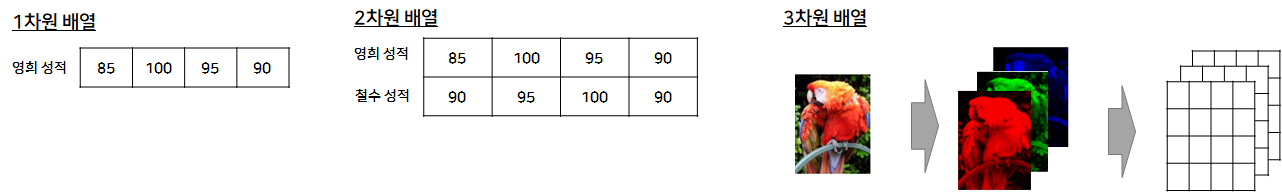

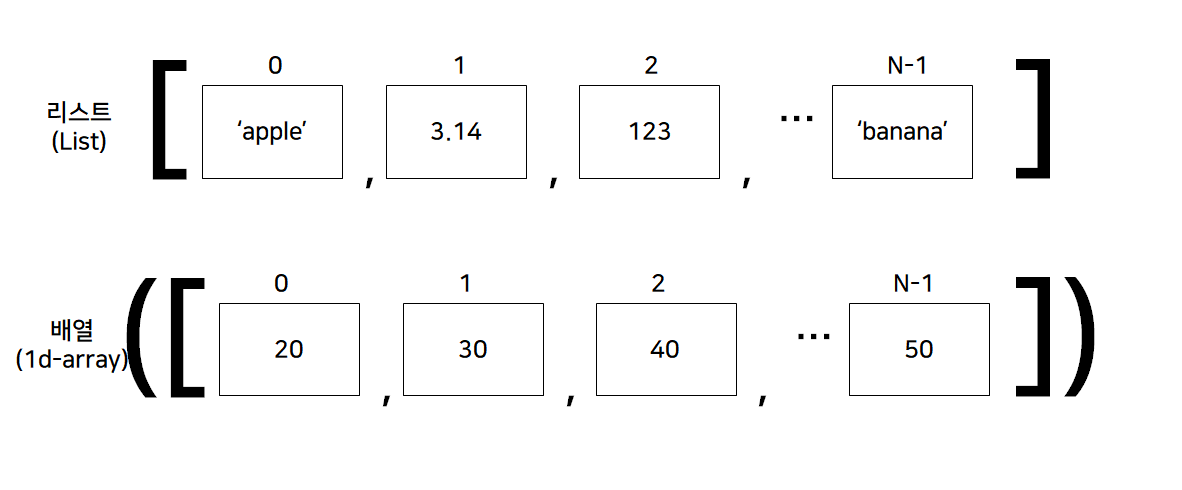

### numpy 패키지 사용

In [ ]:
import numpy as np

In [ ]:
# 리스트 연산 - 반복문 필요
list_data = [1, 2, 3, 4]
result_list = list_data*2  # 반복문 필요
print(result_list)
result_list=[]
for item in list_data:
    result_list.append(item * 2)
print(list_data)
print(result_list)


[1, 2, 3, 4, 1, 2, 3, 4]
[1, 2, 3, 4]
[2, 4, 6, 8]


In [ ]:
# 배열 연산 - 벡터화 연산`
array_data = np.array([1, 2, 3, 4])
result_array = array_data * 2  # 모든 원소에 2를 곱함
print(result_array) #print(array_data*2)

[2 4 6 8]


## np.array() - 기본 배열 생성

In [ ]:
import numpy as np

list1 = [1,2,3]
arr1 = np.array([10,20,30,40])
print(arr1)
print(list1)

[10 20 30 40]
[1, 2, 3]


ndarray를 리스트로 변환

In [ ]:
list1=arr1.tolist()
print(list1)

[10, 20, 30, 40]


## np.zeros() - 0으로 초기화 된 배열

In [ ]:
arr=np.zeros(5, dtype=int)+5 #실수형으로 초기화 됨, np.zeros(5, dtype=int)와 같이 사용하면 정수로 초기화
print(arr)

[5 5 5 5 5]


In [ ]:
arr=np.zeros((2,3),dtype=int)+1
print(arr)

[[1 1 1]
 [1 1 1]]


## np.ones() - 1로 초기화된 배열

In [ ]:
arr=np.ones(7, dtype=int)
print(arr)

[1 1 1 1 1 1 1]


## np.arange() - 연속된 숫자 배열

In [ ]:
arr=np.arange(10)
print(arr)

[0 1 2 3 4 5 6 7 8 9]


## np.random.rand()

np.random 모듈은 파이썬 내장 random 함수의 기능을 확장하여 다양한 종류의 확률분포로부터 랜덤값을 생성할 수 있음

In [ ]:
arr=np.random.rand(2,3,)
print(arr)
arr=np.random.randint(1,46, size=(6))
print(arr)

[[0.85838508 0.7995765  0.758217  ]
 [0.30007421 0.37031341 0.59095835]]
[13  3 19  8 43 14]


## np.reshape()

In [ ]:
arr2 = np.arange(16)
print(arr2)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


In [ ]:
arr=arr2.reshape(4,4)
print(arr)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]


In [ ]:
arr=arr2.reshape(2,2,4)
print(arr)

[[[ 0  1  2  3]
  [ 4  5  6  7]]

 [[ 8  9 10 11]
  [12 13 14 15]]]


## 자재 데이터 관리 프로그램 만들기
* 샘플 데이터 생성 요청 후, 엑셀 파일로 저장
* 저장된 엑셀 파일을 읽어와서 처리


In [ ]:
# pandas : 표(엑셀) 형태의 데이터를 다루기 위한 라이브러리
import pandas as pd

# numpy : 수치 계산을 위한 라이브러리
import numpy as np

# 숫자를 출력할 때 소수점 형식을 기본값으로 설정
# (정수가 100.0처럼 표시되지 않도록 함)
pd.set_option('display.float_format', None)

# ===================================================
# 1. 자재목록 엑셀 파일 생성 (샘플 데이터)
# ===================================================

print("1. 자재목록 엑셀 파일 생성 (샘플 데이터)")

# 자재 정보를 딕셔너리 형태로 저장
# 각 키는 열(Column)이 되고, 리스트는 각 행(Row)의 데이터가 된다.
data = {
    '자재코드': ['M001', 'M002', 'M003', 'M004', 'M005', 'M006', 'M007', 'M008', 'M009', 'M010'],
    '자재명': ['볼트', '너트', '와셔', '강철판', '알루미늄 봉', '구리선', '플라스틱 튜브', '고무 패킹', '나사', '리벳'],
    '단가': [100, 50, 20, 50000, 15000, 10000, 500, 200, 80, 120],
    '재고수량': [100000, 200000, 500000, 500, 1000, 2000, 10000, 5000, 300000, 80000],
    '카테고리': ['부품', '부품', '부품', '소재', '소재', '소재', '부품', '부품', '부품', '부품']
}

# 딕셔너리를 DataFrame(표 형태)로 변환
material_df = pd.DataFrame(data)

# 저장할 엑셀 파일의 경로 지정
excel_file_path = '/content/drive/MyDrive/Colab Notebooks/material_list.xlsx'

# DataFrame을 엑셀 파일로 저장
# index=False는 왼쪽 번호(인덱스)를 저장하지 않겠다는 의미
material_df.to_excel(excel_file_path, index=False)

# 저장 완료 메시지 출력
print(f"샘플 자재 목록이 '{excel_file_path}'에 저장되었습니다.\n")

# ===================================================
# 2. 엑셀 파일 읽기 및 기본 정보 확인
# ===================================================

print("2. 자재목록 엑셀 파일 읽기 및 기본 정보 확인")

# 저장한 엑셀 파일을 다시 불러온다.
loaded_material_df = pd.read_excel(excel_file_path)

# 단가와 재고수량을 정수(int)형으로 변환
# 엑셀을 읽으면 실수(float)로 인식될 수 있기 때문
loaded_material_df['단가'] = loaded_material_df['단가'].astype(int)
loaded_material_df['재고수량'] = loaded_material_df['재고수량'].astype(int)

# 컬럼(열) 이름 출력
print("컬럼 목록:", loaded_material_df.columns.tolist())

# 전체 행(Row)의 개수 출력
print("행 수:", loaded_material_df.shape[0])

# 처음 5개의 데이터 출력
print("상위 5개 행:")
display(loaded_material_df.head())

# 기본 통계 정보 출력
# 평균, 최대값, 최소값 등을 확인할 수 있다.
print("기본 통계:")

display(
    loaded_material_df.describe().style.format({
        '단가': '{:.0f}',
        '재고수량': '{:.0f}'
    })
)

print("\n")

# ===================================================
# 3. 재고금액 계산 및 정렬
# ===================================================

print("3. '재고금액' 컬럼 추가 및 필터링")

# 재고금액 = 단가 × 재고수량
# 새로운 컬럼 '재고금액' 생성
loaded_material_df['재고금액'] = (
    loaded_material_df['단가'] *
    loaded_material_df['재고수량']
)

# 재고금액도 정수형으로 변환
loaded_material_df['재고금액'] = (
    loaded_material_df['재고금액'].astype(int)
)

# 재고금액이 큰 순서(내림차순)로 정렬
sorted_material_df = loaded_material_df.sort_values(
    by='재고금액',
    ascending=False
)

# 상위 5개 출력
print("재고금액 기준으로 내림차순 정렬된 자재 목록 (일부):")
display(sorted_material_df.head())

# ===================================================
# 4. 재고금액이 1,000만원 이상인 자재만 추출
# ===================================================

# 조건을 만족하는 행만 선택
high_value_materials = sorted_material_df[
    sorted_material_df['재고금액'] >= 10000000
]

# 결과 출력
print("\n재고금액이 1,000만원 이상인 자재:")
display(high_value_materials)

1. 자재목록 엑셀 파일 생성 (샘플 데이터)
샘플 자재 목록이 '/content/drive/MyDrive/Colab Notebooks/material_list.xlsx'에 저장되었습니다.

2. 자재목록 엑셀 파일 읽기 및 기본 정보 확인
컬럼 목록: ['자재코드', '자재명', '단가', '재고수량', '카테고리']
행 수: 10
상위 5개 행:


,자재코드,자재명,단가,재고수량,카테고리
0,M001,볼트,100,100000,부품
1,M002,너트,50,200000,부품
2,M003,와셔,20,500000,부품
3,M004,강철판,50000,500,소재
4,M005,알루미늄 봉,15000,1000,소재


기본 통계:


,단가,재고수량
count,10,10
mean,7607,119850
std,15800,167627
min,20,500
25%,85,2750
50%,160,45000
75%,7625,175000
max,50000,500000




3. '재고금액' 컬럼 추가 및 필터링
재고금액 기준으로 내림차순 정렬된 자재 목록 (일부):


,자재코드,자재명,단가,재고수량,카테고리,재고금액
3,M004,강철판,50000,500,소재,25000000
8,M009,나사,80,300000,부품,24000000
5,M006,구리선,10000,2000,소재,20000000
4,M005,알루미늄 봉,15000,1000,소재,15000000
1,M002,너트,50,200000,부품,10000000



재고금액이 1,000만원 이상인 자재:


,자재코드,자재명,단가,재고수량,카테고리,재고금액
3,M004,강철판,50000,500,소재,25000000
8,M009,나사,80,300000,부품,24000000
5,M006,구리선,10000,2000,소재,20000000
4,M005,알루미늄 봉,15000,1000,소재,15000000
1,M002,너트,50,200000,부품,10000000
0,M001,볼트,100,100000,부품,10000000
2,M003,와셔,20,500000,부품,10000000
